In [16]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from adserve_sim.auction.budget import run_budgeted_auction
from adserve_sim.auction.ranking import bid
from adserve_sim.auction.second_price import clear_second_price, run_auction, sample_competing_bids
from adserve_sim.data.schema import LABEL
from adserve_sim.data.split import split_by_day
from adserve_sim.eval.distortion import STANDARD_SCENARIOS
from adserve_sim.features.build import add_time_features, feature_columns
from adserve_sim.models.train import train_model

VALUE_PER_CLICK = 1.0

## 1. Auction: what miscalibration costs

The previous notebook established that a click model can be distorted by a known
amount without any ranking metric noticing. This one prices that distortion.

**The chain.** A click model outputs a probability. A bidder turns it into a bid.
The bid competes. Whoever wins pays, and earns whatever the impression turns out
to be worth. Miscalibration enters at step two and its cost only becomes visible
at step four.

**Who you are here.** One buy-side bidder with a click model, a DSP bidding on
behalf of an advertiser. Rivals are synthetic, drawn from a distribution rather
than modelled, standing in for other buyers whose models you cannot see. The
publisher runs the auction and collects the clearing prices.

Worth naming the tension: the RUNA SDK that shaped this simulator's request
contract is *publisher-side* software, so a faithful simulation of that would put
you in the seller's chair. The buy-side framing is used because the calibration
question is sharper from it, an over-bidding buyer pays real money for
impressions worth less than the price, against a ground truth we actually have.
Publisher revenue is reported alongside, since the same clearing prices answer
both.

The model is retrained here rather than loaded, so this notebook runs standalone.
Roughly four minutes.

In [ ]:
df = pd.read_parquet("../data/processed/avazu_sample.parquet")
split = split_by_day(df, val_days=1, test_days=2)

model, metrics = train_model(split, use_target_encoding=False, log_to_mlflow=False)

test_matrix = add_time_features(split.test)
columns = feature_columns(use_target_encoding=False)

predictions = model.predict_proba(test_matrix[columns])[:, 1]
clicks = split.test[LABEL].to_numpy(dtype=float)
positions = split.test["banner_pos"].to_numpy()

print(
    f"{len(clicks):,} impressions, "
    f"base rate {clicks.mean():.4f}, "
    f"test AUC {metrics['test'].auc:.4f}"
)

0:	test: 0.6308305	best: 0.6308305 (0)	total: 762ms	remaining: 6m 20s
100:	test: 0.7431344	best: 0.7433837 (95)	total: 51s	remaining: 3m 21s
200:	test: 0.7450355	best: 0.7454252 (177)	total: 1m 42s	remaining: 2m 32s
300:	test: 0.7458917	best: 0.7460474 (293)	total: 2m 34s	remaining: 1m 42s
400:	test: 0.7467719	best: 0.7467834 (396)	total: 3m 32s	remaining: 52.3s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7468388193
bestIteration = 408

Shrink model to first 409 iterations.
39,828 impressions, base rate 0.1636, test AUC 0.7261


## 2. Bids, and the market they face

**The bid.** `value_per_click × pCTR × p(viewable)`. The first term is a
parameter, Avazu has no conversion or revenue data, so what a click is worth is
supplied from outside. Set to 1.0, which makes every currency figure below a
multiple of "one click's worth". The third comes from a prior on slot position,
since Avazu has no viewability labels either. Both are stated assumptions, not
measurements.

**The rivals.** Log-normal, because bids are positive and right-skewed: most
cluster near a typical value, a few go much higher. The distribution is centred
on the median *undistorted* bid, and that centring is the important part. If
rivals sat at some fixed absolute level, an over-bidding model would win
everything and the experiment would measure the arbitrary gap between two scales
rather than the cost of being wrong.

Three market depths: 1, 2 and 5 rivals because how many bidders show up turns
out to change whether the reserve price matters at all.

In [3]:
bids = {
    name: bid(d.apply(predictions), positions, VALUE_PER_CLICK)
    for name, d in STANDARD_SCENARIOS.items()
}

reference = float(np.median(bids["none"]))
rivals = {
    n: sample_competing_bids(len(clicks), reference, n_competitors=n, seed=1) for n in (1, 2, 5)
}

print(f"reference bid {reference:.4f}")
display(pd.DataFrame({k: pd.Series(v).describe() for k, v in bids.items()}).round(4))

reference bid 0.1026


,none,over-predict,under-predict,overconfident,underconfident
count,39828.0000,39828.0000,39828.0000,39828.0000,39828.0000
mean,0.1162,0.1556,0.0848,0.0701,0.1832
std,0.0780,0.0943,0.0624,0.0774,0.0677
min,0.0084,0.0125,0.0057,0.0009,0.0479
25%,0.0542,0.0779,0.0374,0.0167,0.1276
50%,0.1026,0.1428,0.0722,0.0460,0.1818
75%,0.1632,0.2185,0.1185,0.1000,0.2298
max,0.6761,0.6988,0.6448,0.7238,0.5929


## 3. The headline: five models, one market

Each scenario bids into the same auctions against the same rivals, at reserve
zero so nothing is filtered out. The only thing that varies is the probability.

**Reading the columns.** *Win rate* is the share of auctions taken. *Spend* is
what was paid, remember this is second-price, so the winner pays the runner-up's
bid, not their own. *Profit* is click value earned minus spend, which is where
over-bidding shows up: you can win more and earn less. *Effective CPC* is spend
per click actually received, and it rises when you buy impressions that do not
convert.

*Publisher revenue* is the other side of the same transaction, counting every
auction that cleared including the ones you lost.

In [4]:
rows = []
for name, b in bids.items():
    s = run_auction(b, clicks, rivals[5], reserve=0.0, value_per_click=VALUE_PER_CLICK)
    rows.append(
        {
            "scenario": name,
            "win rate": s.win_rate,
            "impressions": s.impressions_won,
            "clicks": s.clicks_won,
            "spend": s.advertiser_spend,
            "profit": s.advertiser_profit,
            "ROI": s.roi,
            "eff. CPC": s.effective_cpc,
            "publisher rev": s.publisher_revenue,
        }
    )

headline = pd.DataFrame(rows).set_index("scenario")
display(headline.round(3))

,win rate,impressions,clicks,spend,profit,ROI,eff. CPC,publisher rev
scenario,,,,,,,,
none,0.168,6675,2075,1024.526,1050.474,1.025,0.494,6313.300
over-predict,0.297,11844,3299,1967.927,1331.073,0.676,0.597,6695.724
under-predict,0.076,3037,1116,444.150,671.850,1.513,0.398,6045.395
overconfident,0.071,2843,1116,454.532,661.468,1.455,0.407,6028.588
underconfident,0.386,15366,3692,2482.434,1209.566,0.487,0.672,6957.531


## 4. Reserve price sweep

A **reserve price** is a floor the publisher sets: bids below it lose and the
slot goes unfilled. It is a trade, raising it lifts the price of the auctions
that still clear, at the cost of clearing fewer of them.

Textbook expectation is that publisher revenue is non-monotonic in the reserve:
rising at first as cheap sales are blocked, then falling as too much inventory
goes unsold. Somewhere in between is an optimum.

Whether that optimum is worth anything depends on **how many bidders show up**,
which is why the sweep runs across three market depths. In a thick auction the
runner-up's bid is already close to the winner's, so the price is high without
any floor and a reserve adds little. In a thin one there may be no meaningful
runner-up at all, and the floor is the only thing preventing a cheap sale.

390 auctions run below: 5 scenarios × 3 depths × 26 reserve levels.

In [5]:
reserves = np.linspace(0.0, 0.5, 26)

sweep = pd.DataFrame(
    [
        {
            "scenario": name,
            "competitors": n,
            "reserve": r,
            "profit": s.advertiser_profit,
            "publisher_revenue": s.publisher_revenue,
            "fill_rate": s.fill_rate,
            "win_rate": s.win_rate,
        }
        for name, b in bids.items()
        for n, rv in rivals.items()
        for r in reserves
        for s in [run_auction(b, clicks, rv, reserve=r, value_per_click=VALUE_PER_CLICK)]
    ]
)

## 5. Three views

**Left: profit against reserve.** How each miscalibrated bidder fares as the
floor rises. Watch the gap between scenarios, not the shape of any one line.

**Middle: where a reserve is worth setting.** Publisher revenue against reserve
for the honest bidder at each market depth, with the peak marked. The comparison
between the three lines is the finding.

Right: does the money go somewhere? Advertiser profit against publisher revenue,
one point per scenario. A downward line would mean miscalibration transfers value
from buyer to seller. An upward one means both sides lose together.

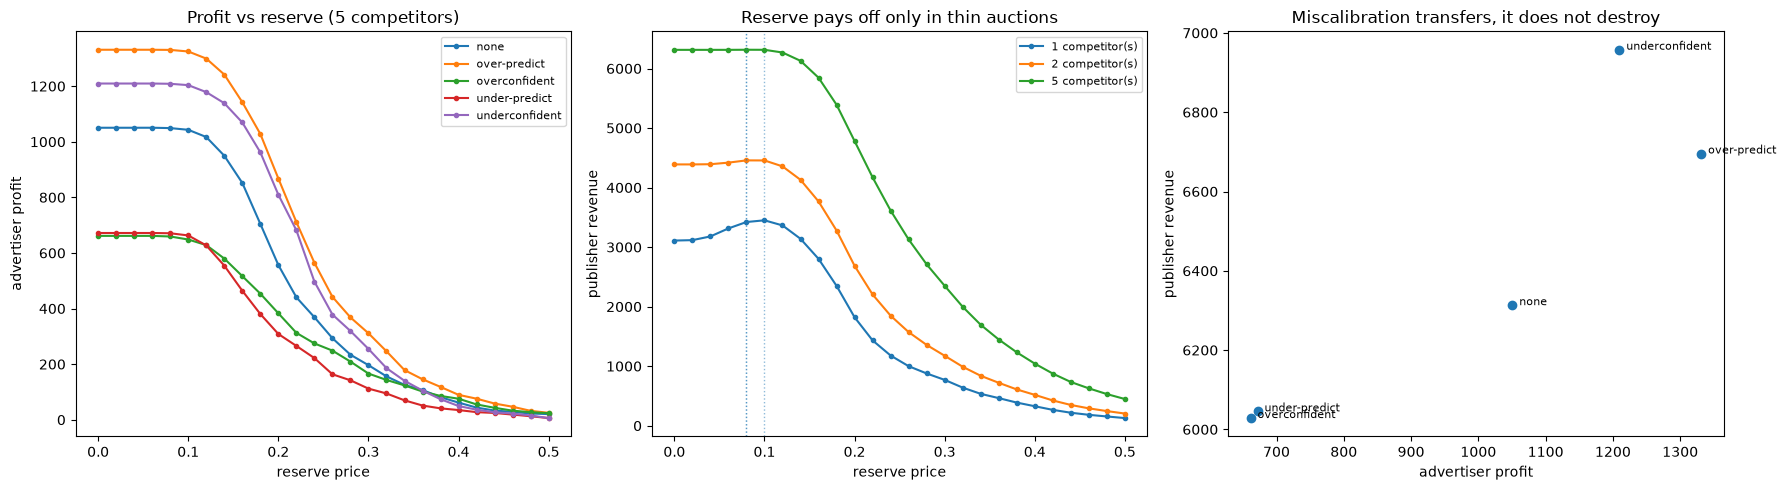

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

thick = sweep[sweep["competitors"] == 5]
for name, group in thick.groupby("scenario"):
    axes[0].plot(group["reserve"], group["profit"], marker="o", markersize=3, label=name)
axes[0].set_xlabel("reserve price")
axes[0].set_ylabel("advertiser profit")
axes[0].set_title("Profit vs reserve (5 competitors)")
axes[0].legend(fontsize=8)

honest = sweep[sweep["scenario"] == "none"]
for n, group in honest.groupby("competitors"):
    axes[1].plot(
        group["reserve"],
        group["publisher_revenue"],
        marker="o",
        markersize=3,
        label=f"{n} competitor(s)",
    )
    peak = group.loc[group["publisher_revenue"].idxmax()]
    axes[1].axvline(peak["reserve"], ls=":", lw=1, alpha=0.5)
axes[1].set_xlabel("Reserve price")
axes[1].set_ylabel("Publisher revenue")
axes[1].set_title("Reserve pays off only in thin auctions")
axes[1].legend(fontsize=8)

axes[2].scatter(headline["profit"], headline["publisher rev"])
for name, row in headline.iterrows():
    axes[2].annotate(
        name,
        (row["profit"], row["publisher rev"]),
        fontsize=8,
        xytext=(5, 0),
        textcoords="offset points",
    )
axes[2].set_xlabel("Advertiser profit")
axes[2].set_ylabel("Publisher revenue")
axes[2].set_title("Profit and publisher revenue move together")

plt.tight_layout()
plt.show()

In [19]:
correlation = headline["profit"].corr(headline["publisher rev"])

print(f"Advertiser profit vs publisher revenue: r = {correlation:+.3f}\n")
display(headline[["profit", "publisher rev"]].sort_values("profit").round(1))

Advertiser profit vs publisher revenue: r = +0.902



,profit,publisher rev
scenario,,
overconfident,661.5,6028.6
under-predict,671.8,6045.4
none,1050.5,6313.3
underconfident,1209.6,6957.5
over-predict,1331.1,6695.7


In [20]:
won_ctr = headline["clicks"] / headline["impressions"]
print(f"\nCTR of impressions won (base rate {clicks.mean():.4f}):")
display(won_ctr.sort_values(ascending=False).round(4))


CTR of impressions won (base rate 0.1636):


scenario
overconfident     0.3925
under-predict     0.3675
none              0.3109
over-predict      0.2785
underconfident    0.2403
dtype: float64

### What the auction prices

Every row of the headline table has **identical AUC**. They differ only in the
magnitude of their probabilities, and the auction turns that into money.

Three things the numbers say.

**Over-prediction wins more and earns more** which is not what this project 
expected. Profit rises from 1050 to 1331, a 27% gain over honest bidding. 
The mechanism is second-price pricing: your bid decides only whether you 
win, never what you pay, so bidding above your true value buys extra 
auctions at prices someone else sets. Efficiency collapses: ROI falls from 
1.03 to 0.68, effective CPC rises from 0.49 to 0.60, and the impressions 
won click at 27.9% against honest bidding's 31.1%, but with unlimited money,
volume more than compensates. Read that as a statement about the market 
rather than about calibration: over-bidding is cheap when rivals rarely 
bid near your valuation. Section 6 removes the unlimited money and the 
ranking inverts.

**Under-prediction is quieter and still costs.** Fewer auctions won, so less
profit in absolute terms even though ROI on what it did win looks better. The
cost is opportunity, and it does not show up in any metric the bidder tracks,
which is the asymmetry that makes under-prediction the more dangerous direction:
losing an auction produces no impression, no click, and therefore no evidence
that anything was wrong.

It is not a transfer. The plausible story here was that money lost by the advertiser
reappears as publisher revenue. The table says otherwise: across the five scenarios
the two correlate at r = +0.90, moving together rather than against each other. 
under-predict has both the lowest advertiser profit and nearly the lowest publisher
revenue. A bidder that stops bidding does not enrich the publisher,it removes a bidder
from the auction, and clearing prices fall for everyone. Left in rather than deleted,
because it was checkable and it was wrong.

And on the reserve: it pays off in thin auctions and does almost nothing in
thick ones. With five rivals the runner-up's bid already captures most of the
available surplus, so a floor is redundant; with one, it is the only thing
standing between the publisher and a cheap sale.

## 6. Budget


In [7]:
unconstrained = run_auction(bids["none"], clicks, rivals[5], value_per_click=VALUE_PER_CLICK)
budgets = {f"{f:.0%}": unconstrained.advertiser_spend * f for f in (1.0, 0.5, 0.25, 0.1)}

In [14]:
order = ["10%", "25%", "50%", "100%"]

budget_rows = []
for label, amount in budgets.items():
    for name, b in bids.items():
        settlement, detail = run_budgeted_auction(
            b,
            clicks,
            rivals[5],
            budget=amount,
            value_per_click=VALUE_PER_CLICK,
        )
        budget_rows.append(
            {
                "budget": label,
                "scenario": name,
                "profit": settlement.advertiser_profit,
                "spend": settlement.advertiser_spend,
                "impressions": settlement.impressions_won,
                "clicks": settlement.clicks_won,
                "ROI": settlement.roi,
                "exhausted_at": detail.exhausted_fraction,
            }
        )

budget_table = pd.DataFrame(budget_rows)

display(budget_table.pivot(index="scenario", columns="budget", values="profit")[order])

budget,10%,25%,50%,100%
scenario,,,,
none,117.659146,245.899056,516.856506,1050.636980
over-predict,73.613576,175.924762,300.779678,656.507203
overconfident,137.557845,370.922550,661.468496,661.468496
under-predict,139.630579,388.987516,671.849955,671.849955
underconfident,56.661817,141.020518,221.822071,444.500770


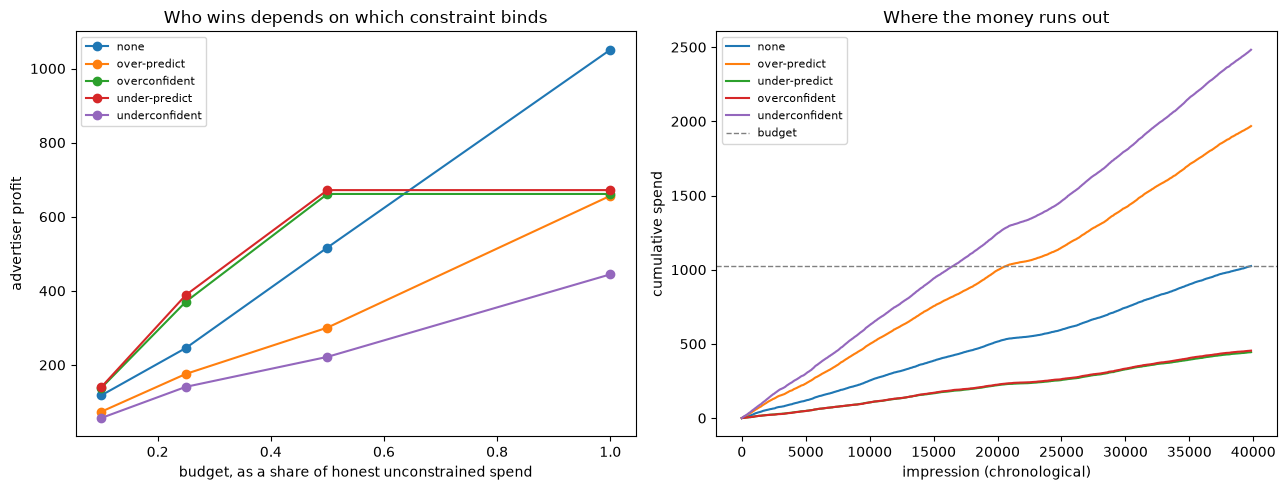

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, group in budget_table.groupby("scenario"):
    ordered = group.set_index("budget").loc[order]
    axes[0].plot([0.1, 0.25, 0.5, 1.0], ordered["profit"], marker="o", label=name)

axes[0].set_xlabel("Budget, as a share of honest unconstrained spend")
axes[0].set_ylabel("Advertiser profit")
axes[0].set_title("Who wins depends on which constraint binds")
axes[0].legend(fontsize=8)

full = budgets["100%"]
for name, b in bids.items():
    outcome = clear_second_price(b, rivals[5], reserve=0.0)
    axes[1].plot(np.cumsum(outcome.price_paid), label=name)

axes[1].axhline(full, ls="--", c="grey", lw=1, label="budget")
axes[1].set_xlabel("Impression (chronological)")
axes[1].set_ylabel("Cumulative spend")
axes[1].set_title("Where the money runs out")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

# What miscalibration costs, and when

Findings from `adserve-sim`. All numbers come from `notebooks/02-baseline-model.ipynb`
and `notebooks/03-auction.ipynb`, run on a 200k-row stratified sample of Avazu
(10 days, October 2014), test window 39,828 impressions at a 16.4% base rate.

---

## The question, and what happened to it

The project set out to answer: **if a click model ranks impressions correctly
but predicts the wrong probabilities, what does that cost once bids compete?**

The premise held. The plan did not survive contact with the data, twice, and
both surprises turned out to be more interesting than the thing they replaced.

---

## Result 1: a well-fitted model is already calibrated, and the data can't test otherwise

CatBoost on the temporal split: test AUC 0.726, log loss 0.4007 against a
constant-predictor baseline of 0.4459, calibration gap **+0.0026** on a 16.4%
base rate. The reliability curve sits on the diagonal everywhere traffic
actually lives.

Two reasons, and neither is luck.

**The fitting was done the way that produces calibration.** `Logloss` is a
proper scoring rule, it penalises wrong probabilities directly rather than only
wrong ordering, and early stopping fired at iteration 408, before the model
could grow confident enough to distort. 

**The dataset cannot contain the failure anyway.** Kaggle's own description
states clicks and non-clicks were subsampled at different rates before release.
The 16.9% overall click rate is real for this file and inflated relative to the
traffic it came from. So a model fitted here is calibrated to a distribution
that does not exist, deployed against real traffic it would over-predict by
roughly two orders of magnitude, which is precisely the failure under study,
except the correction is a log-odds offset of an unpublished constant and cannot
be applied. And 16.9% is a comfortable estimation problem; real display CTR near
0.2% is where probability estimates actually break, and that regime is not in
the file.

**So the miscalibration was manufactured instead.** Distort a good model by a
known amount, affine in log-odds: `a·logit(p) + b`. Monotone for any positive
`a`, so the ranking (and therefore AUC) is unchanged by construction.

This is the stronger design regardless of what the baseline had done. "My model
happened to be miscalibrated and here is the fix" is an anecdote whose size
depends on which model got trained. A cost curve is a controlled experiment.

---

## Result 2: AUC cannot see any of it

| scenario | AUC | mean prediction |
|---|---|---|
| none | 0.7261 | 0.116 |
| over-predict (`b = +0.4`) | 0.7261 | 0.156 |
| under-predict (`b = −0.4`) | 0.7261 | 0.085 |
| overconfident (`a = 1.5`) | 0.7261 | 0.070 |
| underconfident (`a = 0.6`) | 0.7261 | 0.183 |

Identical to four decimal places. Mean prediction ranges from 0.070 to 0.183 —
a factor of 2.6 across five models a ranking metric cannot distinguish.

Plotted, five ROC curves collapse into a single visible line while five
reliability curves fan apart. A team tracking AUC release over release would see
one model here and nothing to investigate.

---

## Result 3: without a budget, over-predicting is *more* profitable

This is the opposite of what the project expected, and it is not a bug.

| scenario | win rate | impressions | spend | profit | ROI | eff. CPC |
|---|---|---|---|---|---|---|
| none | 16.8% | 6,675 | 1,024.5 | **1,050.5** | 1.025 | 0.494 |
| over-predict | 29.7% | 11,844 | 1,967.9 | **1,331.1** | 0.676 | 0.597 |
| under-predict | 7.6% | 3,037 | 444.2 | 671.9 | 1.513 | 0.398 |
| overconfident | 7.1% | 2,843 | 454.5 | 661.5 | 1.455 | 0.407 |
| underconfident | 38.6% | 15,366 | 2,482.4 | 1,209.6 | 0.487 | 0.672 |

Over-predicting is **27% more profitable** than honest bidding.

The mechanism is second-price pricing. Your bid decides only *whether* you win,
never *what you pay*, so the price is the runner-up's bid. Bidding above your true
value therefore wins extra auctions at prices someone else sets, and each extra
win is still profitable so long as the clearing price stays below what the
impression was really worth. Efficiency collapses, ROI falls from 1.03 to 0.68,
effective CPC rises from 0.49 to 0.60, but with unlimited money, volume more
than compensates.

Read that as a statement about the market rather than about calibration:
**over-bidding is cheap when rivals rarely bid near your valuation.** The
competing-bid distribution here is log-normal centred on the honest median, and
under those conditions the marginal auction is usually still worth taking.

---

## Result 4: with a budget, the ranking inverts, and inverts differently at different levels

Advertiser profit, budget expressed as a share of what honest bidding spends
unconstrained:

| scenario | 10% | 25% | 50% | 100% | unlimited |
|---|---|---|---|---|---|
| none | 117.7 | 245.9 | 516.9 | **1,050.6** | 1,050.5 |
| over-predict | 73.6 | 175.9 | 300.8 | 656.5 | **1,331.1** |
| under-predict | **139.6** | **389.0** | **671.8** | 671.8 | 671.9 |
| overconfident | 137.6 | 370.9 | 661.5 | 661.5 | 661.5 |
| underconfident | 56.7 | 141.0 | 221.8 | 444.5 | 1,209.6 |

Over-predicting goes from **+27% to −37%** the moment a cap equal to honest
spending is imposed. Unlimited money was an unstated assumption doing a great
deal of work.

Two mechanisms, and the second is the more interesting.

**Over-bidding exhausts the budget early.** Same money, spent sooner, on worse
value, and then out of the market entirely for the rest of the period. The
cost of miscalibration is not what you overpay, it is what you can no longer
afford.

**Timidity becomes a virtue when money is the binding constraint.** Under-predict
and overconfident beat honest bidding at 10%, 25% and 50%, and their profit is
identical at 50% and 100% because they never reach the cap at all; too cautious
to spend it. Their advantage is quality: the impressions they win click at 36.8%
and 39.3% respectively, against 31.1% for honest bidding and 27.9% for
over-prediction. Bidding low is an accidental filter for good inventory.

So there is no direction of error that is safe in both regimes. Which
miscalibration hurts depends on **whether the budget binds**, whether you run
out of money before you run out of worthwhile impressions.

---

## Result 5: a reserve price is worth setting only in thin auctions

Publisher revenue against reserve, honest bidder, three market depths:

| rivals | peak revenue | at reserve | vs. no reserve |
|---|---|---|---|
| 1 | 4,971.7 | 0.15 | **+8.6%** |
| 2 | 6,448.3 | 0.10 | +1.0% |
| 5 | 9,164.2 | 0.10 | +0.003% |

The textbook non-monotonicity appears; revenue rises then falls, but with five
rivals the peak is indistinguishable from setting no floor at all. The reason is
structural: in a thick auction the runner-up's bid is already close to the
winner's, so the second price captures most of the available surplus and a floor
has nothing left to extract. In a thin one there may be no meaningful runner-up,
and the reserve is the only thing standing between the publisher and a cheap
sale.

Worth stating as a caution about the check itself: "revenue is non-monotonic in
the reserve" is true and nearly useless as a validation test, because the effect
size at realistic competition levels is a rounding error.

---

## A claim the data does not support

An earlier draft of the auction notebook asserted that **miscalibration
transfers money from advertiser to publisher rather than destroying it**, that
scenarios losing advertiser profit would raise publisher revenue.

The data says otherwise. Across the five scenarios, advertiser profit and
publisher revenue correlate at **r = +0.90**: they move together. `under-predict`
has both the lowest profit (671.9) and nearly the lowest publisher revenue
(6,045.4). A bidder that stops bidding does not enrich the publisher, it removes
a bidder from the auction, which lowers clearing prices for everyone.

The transfer story was a plausible-sounding intuition that survived until it was
checked against the numbers in the table directly above it. It is recorded here
rather than quietly deleted, since being wrong in a legible way is the point of
writing findings down.

---

## Limitations

**The dataset cannot contain the failure being studied.** Kaggle's subsampling
means absolute probability claims are meaningless here. Relative comparisons
survive; every scenario sits in the same distorted distribution but nothing in
this repo should be read as a statement about real click rates.

**One label per impression.** Avazu records whether the impression shown was
clicked, so the model scores the *opportunity*. A real ad server scores this ad,
in this slot, for this context, and the same impression gets a different pCTR for
each competing campaign. Creative features are the missing input and no public
dataset carries them.

**Buy-side framing, which is the wrong chair for an in-house platform.** An
in-house ad server predicts pCTR itself, ranks campaigns and sets the price so
its calibration is not an internal quality metric but a pricing decision imposed
on advertisers who cannot audit it. The same arithmetic, from the other side.
Measured buy-side because ground truth exists there: the click either happened or
it did not.

**Every market parameter is invented.** Competing bids, viewability, the value
of a click, the number of rivals. Each is stated where it is used, in code, with
the reasoning attached. None is fitted, and the sensitivity analysis around them
is not run.

**The results are conditional, not universal.** The calibration comparison is
robust to the click value, since a constant multiplies every bid equally and
cancels. The auction results are not: which scenario wins depends on the budget
level, and the reserve finding depends on the competing-bid spread. These are
conclusions about *conditions*.

---

## Open questions

**Needing server access or production logs:**

- Is the reserve price set per format, per placement, or globally? Three ad
  formats with different attention profiles suggest per-format; the sweep here
  assumes global.
- Does viewability feed the ranker, or is it only measured after the fact? An
  IAB Open Measurement adapter proves it is *measured*. Whether it is *predicted
  at decision time* determines whether the third term in `bid × pCTR ×
  p(viewable)` exists at all.
- What does the attribution window look like? Beacon timing implies conversions
  arrive well after the impression (the delayed-label problem) and window
  length changes how a model should be trained.

**Answerable here, and not yet done:**

- How much does the viewability prior matter? The function takes an override and
  nothing uses it.
- Does the reserve optimum differ by `banner_pos`? That is the testable analogue
  of the per-format question.
- Does the explicit out-of-fold encoder beat CatBoost's native handling? Both
  are implemented; only the native path has been run at scale.
- Do `C14`, `C17`, `C20` and `C21` carry ordinal information? The EDA found
  significant negative rank correlation between their numeric value and CTR,
  suggesting `str` encoding discards signal.

---

## Next steps, in order

1. **Sensitivity analysis on the invented parameters.** Sweep the viewability
   prior and the competing-bid spread, and report which conclusions move. 
2. **Per-`banner_pos` reserve sweep**, as the testable form of the per-format
   argument.
3. **A real pacing controller.** `pacing_rate` is a fixed participation rate set
   up front; a production pacer uses feedback on realised spend against a target
   curve. Given that the hourly traffic profile varies 2.9× peak to trough, a
   fixed rate is visibly the wrong shape.
4. **Selection bias.** Nothing here addresses it, and it is a different failure
   from miscalibration: a model can be perfectly calibrated on the impressions it
   won and systematically blind to the ones it stopped bidding on. Under-prediction
   is self-perpetuating for exactly this reason; no win, no impression, no
   evidence. Logged propensities and doubly-robust estimation are the standard
   route.
5. **Lower base rates.** Every result here sits at 16.4%. Real display CTR is
   two orders of magnitude lower, and that is the regime where probability
   estimates actually degrade. A synthetic downsample would test whether these
   conclusions hold where they matter.

